In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [73]:
path = kagglehub.dataset_download(
    "asaniczka/uk-optimal-product-price-prediction"
)

print(path)

/Users/salvadorciaurrizgonzalez/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [74]:
import os

os.listdir(path)

['amz_uk_price_prediction_dataset.csv']

In [75]:
df = pd.read_csv(
    path + "/amz_uk_price_prediction_dataset.csv"
)

In [76]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [78]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [79]:
category_freq = df['category'].value_counts()

category_freq.head()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

In [80]:
top_5_categories = category_freq.head(5)

top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

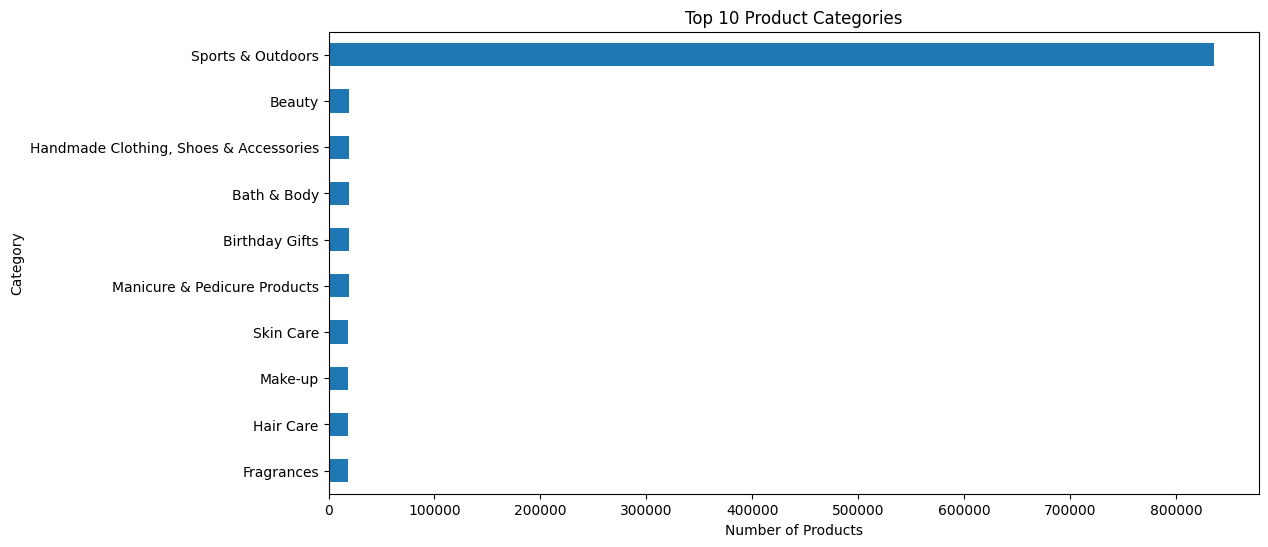

In [81]:
plt.figure(figsize=(12,6))

top_10_categories.sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.show()

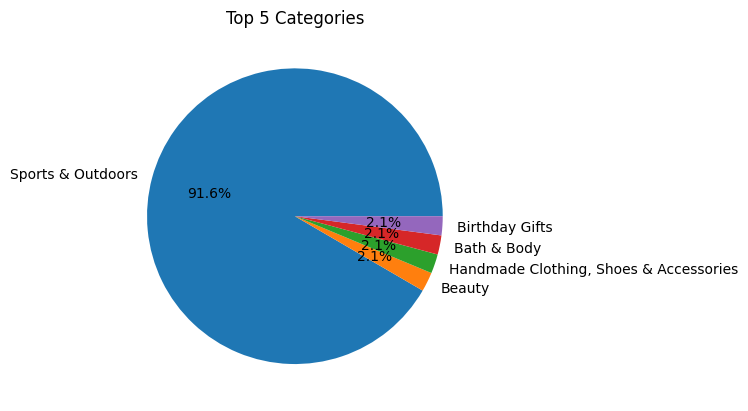

In [82]:
top_5_categories.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Top 5 Categories")

plt.show()

The marketplace is highly concentrated in a few categories.

The top 5 categories represent a significant proportion of all listings, although no single category completely dominates the platform.

In [83]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 89.24380943923663
Median: 19.09
Mode: 9.99


In [84]:
variance_price = df['price'].var()

std_price = df['price'].std()

range_price = (
    df['price'].max()
    - df['price'].min()
)

iqr_price = (
    df['price'].quantile(0.75)
    - df['price'].quantile(0.25)
)

print("Variance:", variance_price)
print("Std:", std_price)
print("Range:", range_price)
print("IQR:", iqr_price)

Variance: 119445.48532254907
Std: 345.60886175349884
Range: 100000.0
IQR: 36.0


Due to the very large size of the dataset, a random sample of 10,000 products was used for visualization purposes in order to improve readability and performance while maintaining representative trends.

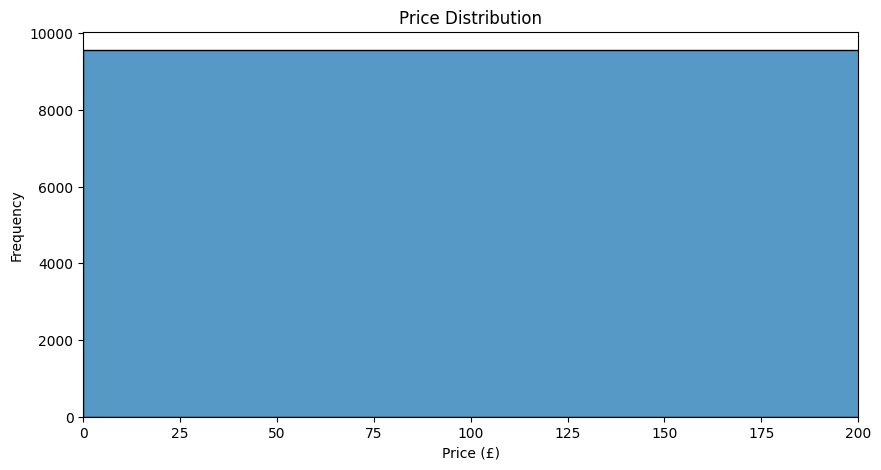

In [85]:
plt.figure(figsize=(10,5))

sns.histplot(sample_prices, bins=30)

plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")

plt.xlim(0, 200)

plt.show()

The distribution is positively skewed.

The mean price is significantly higher than the median, indicating the presence of expensive outliers that increase the average price.

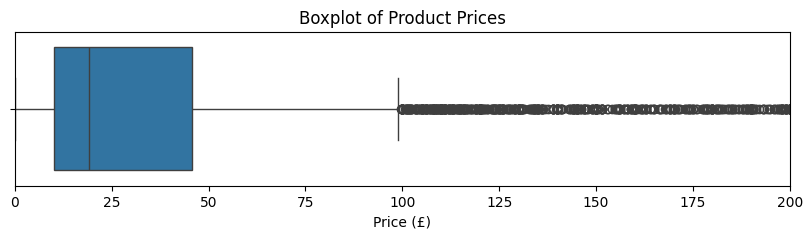

In [86]:
plt.figure(figsize=(10,2))

sns.boxplot(x=sample_prices)

plt.title("Boxplot of Product Prices")
plt.xlabel("Price (£)")

plt.xlim(0, 200)

plt.show()

There are significant outliers, meaning some products are priced much higher than the majority.

In [87]:
mean_rating = df['stars'].mean()

median_rating = df['stars'].median()

mode_rating = df['stars'].mode()[0]

print(mean_rating)
print(median_rating)
print(mode_rating)

2.152836472966065
0.0
0.0


In [88]:
variance_rating = df['stars'].var()

std_rating = df['stars'].std()

iqr_rating = (
    df['stars'].quantile(0.75)
    - df['stars'].quantile(0.25)
)

print(variance_rating)
print(std_rating)
print(iqr_rating)

4.817434029796862
2.1948653785134207
4.4


In [89]:
skewness = df['stars'].skew()

kurtosis = df['stars'].kurt()

print(skewness)
print(kurtosis)
if skewness < 0:
    print("The distribution is negatively skewed.")

else:
    print("The distribution is positively skewed.")

0.08120735761080985
-1.9260061280432985
The distribution is positively skewed.


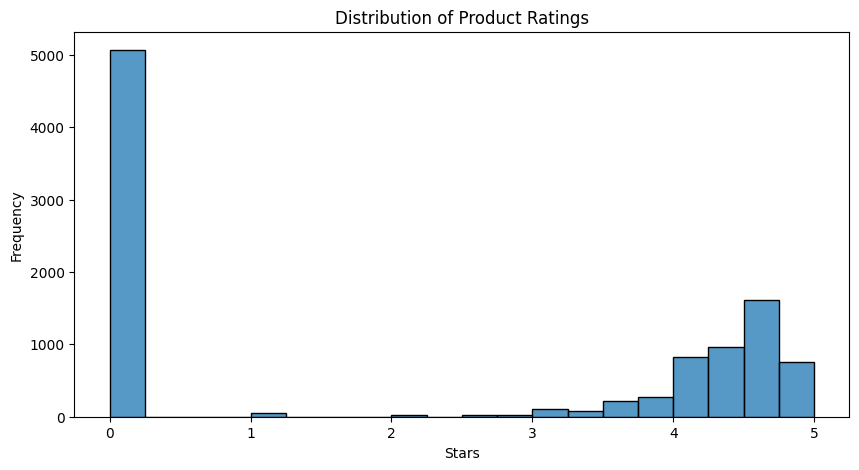

In [90]:
plt.figure(figsize=(10,5))

sns.histplot(sample_stars, bins=20)

plt.title("Distribution of Product Ratings")
plt.xlabel("Stars")
plt.ylabel("Frequency")

plt.show()

Ratings are concentrated around high values, suggesting that customers generally leave positive reviews.

The negative skewness confirms that most ratings are located near the upper end of the scale.

Additionally, the presence of products with 0-star ratings may influence the overall distribution and centrality measures.

## Conclusion

Amazon UK product listings are highly concentrated in a limited number of categories, although no single category completely dominates the marketplace.

Product prices show a strong positive skew, with most products concentrated in lower price ranges and a smaller number of expensive outliers significantly increasing the average price.

Customer ratings are generally very positive, with ratings heavily concentrated around high star values. The negative skewness of the ratings distribution suggests that most products receive favorable feedback from customers.

Overall, the dataset reveals clear patterns in product distribution, pricing behavior, and customer satisfaction that could help businesses improve pricing strategies and category positioning.